<a href="https://colab.research.google.com/github/polreig/StartUp_DecoAI/blob/main/2_Generacion_Imagen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instalamos diffusers de Hugging Face

In [1]:
!pip install -q diffusers transformers accelerate opencv-python

## Función para extraer la estructura
ControlNet necesita ver la estructura de la habitación. Para esto, usamos un filtro llamado Canny Edge Detector que dibuja las líneas maestras de la foto original (paredes, ventanas, cama).

In [6]:
import cv2
import numpy as np
from PIL import Image
import requests
from io import BytesIO

def extraer_estructura(ruta_o_url):
    # Cargar imagen (URL o local)
    if ruta_o_url.startswith('http'):
        response = requests.get(ruta_o_url)
        imagen_original = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        imagen_original = Image.open(ruta_o_url).convert("RGB")

    # Convertir a formato de OpenCV (matriz de números)
    imagen_cv = np.array(imagen_original)

    # Aplicar el filtro Canny para sacar los bordes
    bordes = cv2.Canny(imagen_cv, 100, 200)

    # Convertir de vuelta a imagen para que la entienda ControlNet
    bordes_3d = np.stack([bordes, bordes, bordes], axis=2)
    imagen_bordes = Image.fromarray(bordes_3d)

    return imagen_original, imagen_bordes

Prueba estructura

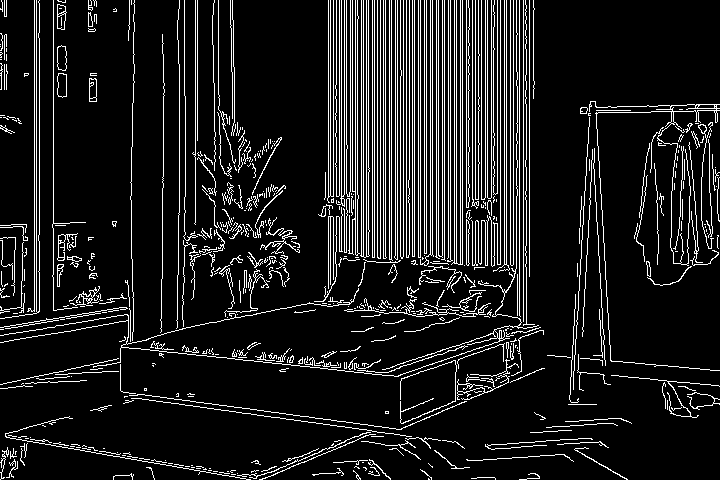

In [10]:
url_prueba = "https://concept-u.es/cdn/shop/articles/habitacion-comoda.webp?v=1703692446"
img_original, img_bordes = extraer_estructura(url_prueba)

display(img_bordes)

## Descargar modelo y generar imagen

In [13]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel

# Cargamos el modelo ControlNet específico para bordes (Canny)
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

# Cargamos el modelo generador (Stable Diffusion 1.5) y lo unimos a ControlNet
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
)

# Lo movemos a la GPU para que sea rápido
pipe = pipe.to("cuda")

# Función para generar la nueva habitación
def generar_nueva_habitacion(imagen_bordes, prompt_estilo):
    # Añadimos palabras clave para asegurar buena calidad
    prompt_final = prompt_estilo + ", interior design, realistic, highly detailed, 8k, professional photography"
    prompt_negativo = "low quality, bad anatomy, worst quality, cartoon, illustration, distorted"

    print("Generando imagen...")
    imagen_generada = pipe(
        prompt_final,
        negative_prompt=prompt_negativo,
        image=imagen_bordes,
        num_inference_steps=25
    ).images[0]

    return imagen_generada

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prueba final

Generando imagen...


  0%|          | 0/25 [00:00<?, ?it/s]

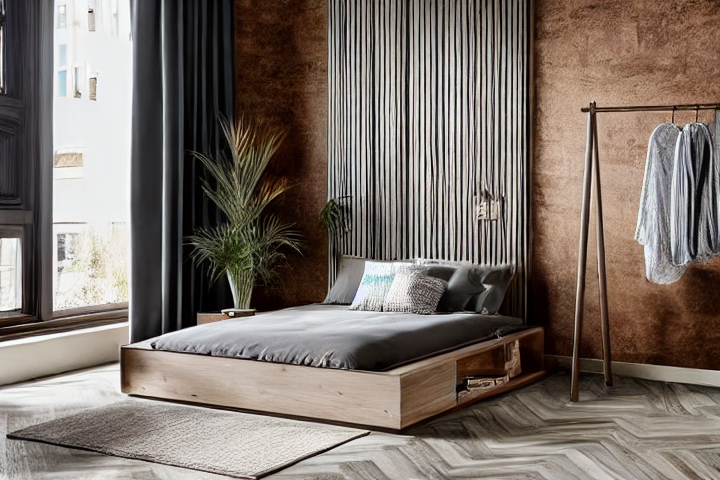

In [14]:
# Usamos el estilo que nos recomendó el modelo de visión en el Cuaderno 1
estilo_recomendado = "estilo **Boho-Chic Contemporáneo**, que te permitirá incorporar color y texturas orgánicas manteniendo la base de tus muebles actuales y añadiendo una sensación de calidez y personalidad relajada."

imagen_final = generar_nueva_habitacion(img_bordes, estilo_recomendado)

# Mostramos el resultado
display(imagen_final)